# Feature Level Analysis & False Positve Reduction

In [ ]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

from sklearn.metrics import classification_report
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from scripts.config import *

## 1. Load data and model

In [ ]:
fp_windows = pd.read_csv(PROCESSED_DIR / 'fp_windows.csv', index_col=0)
fn_windows = pd.read_csv(PROCESSED_DIR / 'fn_windows.csv', index_col=0)

df_full = pd.read_csv(PROCESSED_DIR / 'full_windowed.csv')
normal_windows = pd.read_csv(PROCESSED_DIR / 'normal_windowed.csv')

eval_set = pd.read_csv(PROCESSED_DIR / 'eval_results.csv', index_col=0)

feature_cols = [col for col in df_full.columns
                if col not in ['window_id', 'window_attack']]

pure_normal = df_full[df_full['window_attack'] == 0]
pure_attack = df_full[df_full['window_attack'] == 1]

pure_attack = pure_attack[pure_attack.index > 1000]

iso = joblib.load(MODEL_DIR / 'isolation_forest.pkl')
scaler = joblib.load(MODEL_DIR / 'scaler.pkl')

X_eval_scaled = scaler.transform(eval_set[feature_cols])
X_fp_scaled = scaler.transform(fp_windows[feature_cols])

## 2. Feature level Analysis
### SHAP (SHapley Additive exPlanations)

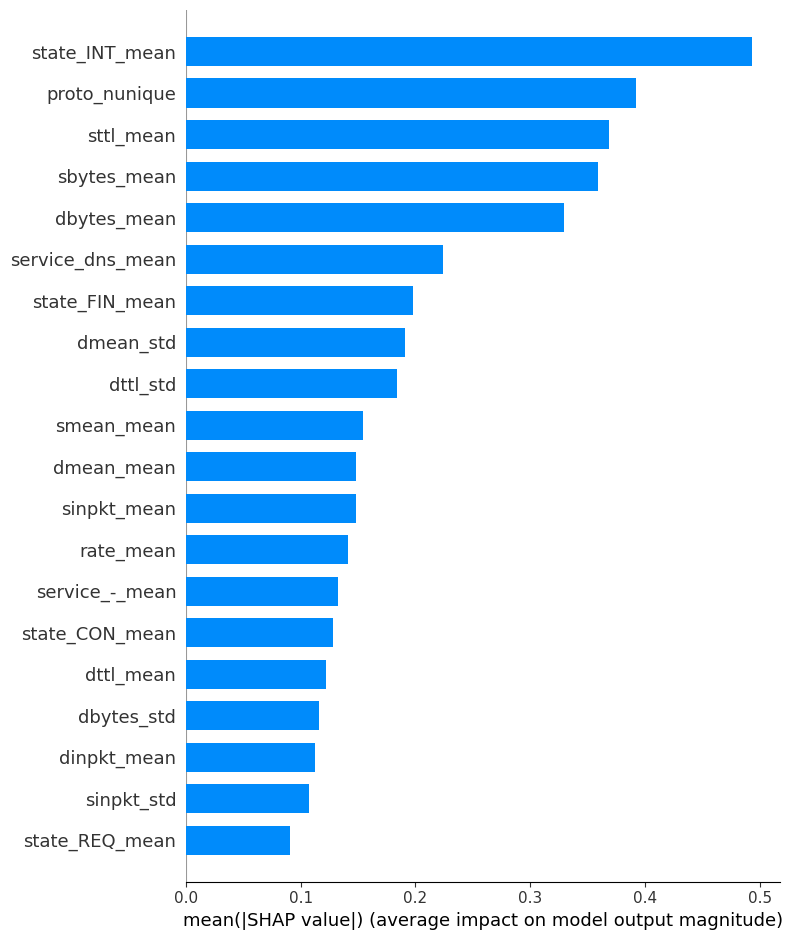

<Figure size 640x480 with 0 Axes>

In [ ]:
explainer = shap.TreeExplainer(iso)
shap_values_eval = explainer.shap_values(X_eval_scaled)
shap_values_fp = explainer.shap_values(X_fp_scaled)

shap.summary_plot(shap_values_eval, eval_set[feature_cols], plot_type='bar', title='Feature Importance')

plt.savefig(FIG_DIR / "feature_importance.png", dpi=300, bbox_inches='tight')

In [ ]:
top_features = ['state_INT_mean', 'proto_nunique', 'sttl_mean', 
                'sbytes_mean', 'dbytes_mean', 'service_dns_mean']

comparison = pd.DataFrame({
    'true_normal_mean': pure_normal[top_features].mean(),
    'fp_mean': fp_windows[top_features].mean(),
    'true_attack_mean': pure_attack[top_features].mean()
})

print(comparison)

                  true_normal_mean     fp_mean  true_attack_mean
state_INT_mean            0.044697    0.223947          0.747558
proto_nunique             2.407098    2.631579          6.310757
sttl_mean                62.334175  180.867895        227.908243
sbytes_mean               7.196469    6.607423          5.560432
dbytes_mean               7.426189    4.054634          1.683050
service_dns_mean          0.156409    0.004474          0.525261


In [ ]:
print("\nFP windows vs Normal windows — feature comparison:\n")

fp_vs_normal = pd.DataFrame({
    'normal_mean': pure_normal[feature_cols].mean(),
    'fp_mean': fp_windows[feature_cols].mean()
})

fp_vs_normal['difference'] = abs(fp_vs_normal['fp_mean'] - fp_vs_normal['normal_mean'])

print(fp_vs_normal.sort_values('difference', ascending=False).head(10))


FP windows vs Normal windows — feature comparison:

             normal_mean     fp_mean  difference
sttl_mean      62.334175  180.867895  118.533719
dttl_mean      53.212630  143.789211   90.576580
dttl_std       28.666543   81.852844   53.186301
sttl_std       28.719502   57.111767   28.392265
dbytes_mean     7.426189    4.054634    3.371555
sinpkt_mean     1.796831    3.967462    2.170631
dmean_mean      4.859813    2.772214    2.087599
rate_mean       6.490992    4.734835    1.756157
dinpkt_mean     1.572304    2.575674    1.003370
rate_std        2.024855    2.909825    0.884971


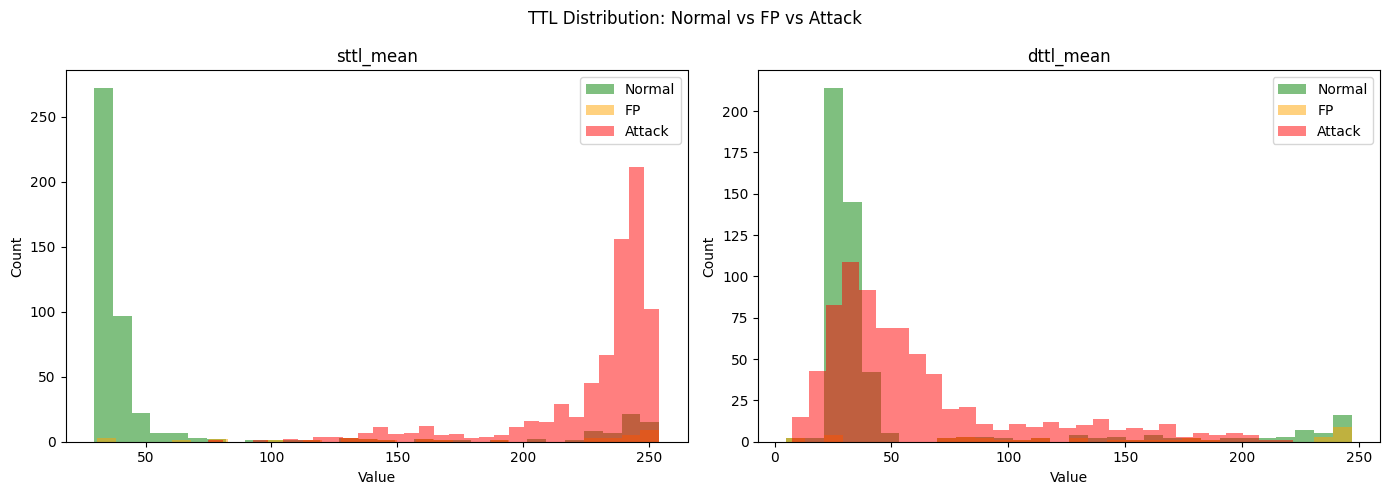

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['sttl_mean', 'dttl_mean']):
    ax.hist(pure_normal[col], bins=30, alpha=0.5, label='Normal', color='green')
    ax.hist(fp_windows[col], bins=30, alpha=0.5, label='FP', color='orange')
    ax.hist(pure_attack[col], bins=30, alpha=0.5, label='Attack', color='red')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend()

plt.savefig(FIG_DIR / "ttl_distribution.png", dpi=300, bbox_inches='tight')
plt.suptitle('TTL Distribution: Normal vs FP vs Attack')
plt.tight_layout()
plt.show()

In [ ]:
for col in ['sttl_mean', 'dttl_mean']:
    mean = pure_normal[col].mean()
    std = pure_normal[col].std()
    low, high = mean - 2*std, mean + 2*std
    
    fp_outside = ((fp_windows[col] < low) | (fp_windows[col] > high)).sum()
    attack_outside = ((pure_attack[col] < low) | (pure_attack[col] > high)).sum()
    normal_outside = ((pure_normal[col] < low) | (pure_normal[col] > high)).sum()
    
    print(f"\n{col} normal range: [{low:.2f}, {high:.2f}]")
    print(f"FPs outside range:     {fp_outside}/{len(fp_windows)} ({fp_outside/len(fp_windows):.1%})")
    print(f"Attacks outside range: {attack_outside}/{len(pure_attack)} ({attack_outside/len(pure_attack):.1%})")
    print(f"Normals outside range: {normal_outside}/{len(pure_normal)} ({normal_outside/len(pure_normal):.1%})")


sttl_mean normal range: [-70.60, 195.27]
FPs outside range:     20/38 (52.6%)
Attacks outside range: 668/753 (88.7%)
Normals outside range: 54/479 (11.3%)

dttl_mean normal range: [-62.25, 168.68]
FPs outside range:     15/38 (39.5%)
Attacks outside range: 32/753 (4.2%)
Normals outside range: 41/479 (8.6%)


In [ ]:
def compute_deviation_score(row, normal_df, features):
    score = 0
    for col in features:
        mean = normal_df[col].mean()
        std = normal_df[col].std() + 1e-10
        score += abs((row[col] - mean) / std)  # z-score contribution
    return score / len(features)

top_features = ['sttl_mean', 'dttl_mean', 'dttl_std', 
                'sttl_std', 'dbytes_mean', 'sinpkt_mean']

eval_set['deviation_score'] = eval_set.apply(
    lambda row: compute_deviation_score(row, pure_normal, top_features), axis=1
)

fp_windows['deviation_score'] = fp_windows.apply(
    lambda row: compute_deviation_score(row, pure_normal, top_features), axis=1
)

pure_normal['deviation_score'] = pure_normal.apply(
    lambda row: compute_deviation_score(row, pure_normal, top_features), axis=1
)

pure_attack['deviation_score'] = pure_attack.apply(
    lambda row: compute_deviation_score(row, pure_normal, top_features), axis=1
)

print("FP deviation scores:")
print(fp_windows['deviation_score'].describe())

print("\nNormal deviation scores:")
print(pure_normal['deviation_score'].describe())

print("\nAttack deviation scores:")
print(pure_attack['deviation_score'].describe())

In [ ]:
fp_vs_attack = pd.DataFrame({
    'fp_mean': fp_windows[feature_cols].mean(),
    'attack_mean': pure_attack[feature_cols].mean(),
}).assign(
    difference=lambda x: abs(x['fp_mean'] - x['attack_mean'])
).sort_values('difference', ascending=False)

print(fp_vs_attack.head())

                  fp_mean  attack_mean  difference
dttl_mean      143.789211    60.499990   83.289220
sttl_mean      180.867895   227.908243   47.040348
dttl_std        81.852844    97.337243   15.484399
rate_mean        4.734835     9.304613    4.569777
proto_nunique    2.631579     6.310757    3.679178


## 3. False Positive Reduction - Rule Based

In [ ]:
def is_likely_fp(row):

    fp_score = 0
    if row['dttl_mean'] > 120: fp_score += 1
    if row['proto_nunique'] < 3: fp_score += 1
    if row['rate_mean'] < 3: fp_score += 1
    if row['sinpkt_mean'] > 3: fp_score += 1
    
    return fp_score >= 3

flagged = eval_set[eval_set['tuned_pred'] == 1].copy()
flagged['is_likely_fp'] = flagged.apply(
    lambda row: is_likely_fp(row), axis=1
)

eval_set['refined_pred'] = eval_set['tuned_pred'].copy()
eval_set.loc[flagged[flagged['is_likely_fp']].index, 'refined_pred'] = 0

print(f"Windows downgraded from alert to normal: {flagged['is_likely_fp'].sum()}")

Windows downgraded from alert to normal: 11


In [12]:
print("=== Baseline IF Results ===")
print(classification_report(eval_set['window_attack'], eval_set['tuned_pred']))

print("=== After FP Reduction ===")
print(classification_report(eval_set['window_attack'], eval_set['refined_pred']))

print(f"Windows downgraded: {flagged['is_likely_fp'].sum()}")
print(f"Of those, true FPs correctly removed: {(flagged[flagged['is_likely_fp']]['window_attack'] == 0).sum()}")
print(f"True attacks incorrectly removed: {(flagged[flagged['is_likely_fp']]['window_attack'] == 1).sum()}")

=== Baseline IF Results ===
              precision    recall  f1-score   support

           0       1.00      0.92      0.96       479
           1       0.95      1.00      0.97       753

    accuracy                           0.97      1232
   macro avg       0.97      0.96      0.97      1232
weighted avg       0.97      0.97      0.97      1232

=== After FP Reduction ===
              precision    recall  f1-score   support

           0       0.99      0.94      0.96       479
           1       0.96      0.99      0.98       753

    accuracy                           0.97      1232
   macro avg       0.98      0.97      0.97      1232
weighted avg       0.97      0.97      0.97      1232

Windows downgraded: 11
Of those, true FPs correctly removed: 9
True attacks incorrectly removed: 2


In [ ]:
caught_fp = flagged[(flagged['is_likely_fp']) & (flagged['window_attack'] == 0)]

print("Caught FP feature profile:\n")
print(caught_fp[['dttl_mean','proto_nunique',
                 'rate_mean','sinpkt_mean',
                 'sttl_mean','dbytes_mean']].describe())    

## 4. PCA (Principle Component Analysis) Visualization

In [14]:
remaining_fp = eval_set[(eval_set['window_attack'] == 0) & (eval_set['refined_pred'] == 1)]

groups = {
    'Normal': pure_normal,
    'Attack': pure_attack,
    'Caught FP': caught_fp,
    'Remaining FP': remaining_fp
}

all_data = pd.concat(groups.values())
X_pca = scaler.transform(all_data[feature_cols])

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_pca)

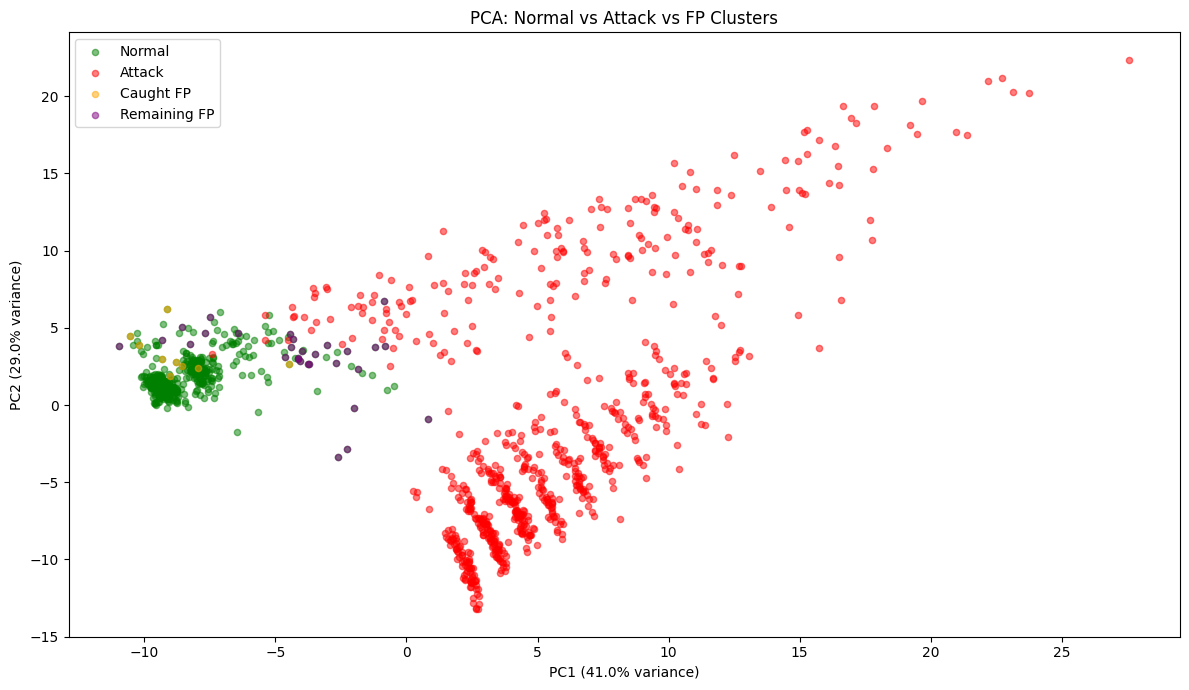

Variance explained by 2 components: 70.0%


<Figure size 640x480 with 0 Axes>

In [15]:
plt.figure(figsize=(12, 7))

colors = {'Normal': 'green', 
          'Attack': 'red', 
          'Caught FP': 'orange', 
          'Remaining FP': 'purple'}

start = 0
for name, group in groups.items():
    end = start + len(group)
    plt.scatter(coords[start:end, 0], coords[start:end, 1],
                label=name, alpha=0.5, s=20, color=colors[name])
    start = end

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA: Normal vs Attack vs FP Clusters')
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig(FIG_DIR / "pca_fp_analysis.png", dpi=300, bbox_inches='tight')
print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum():.1%}")

## 4. Stage 2 - Random Forest Classifier

In [ ]:
flagged_windows = eval_set[eval_set['tuned_pred'] == 1].copy()

X_stage2 = flagged_windows[feature_cols]
y_stage2 = flagged_windows['window_attack']

rf = RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced')
# Cross validation
scores = cross_val_score(rf, X_stage2, y_stage2, cv=5, scoring='f1')

rf.fit(X_stage2, y_stage2)

print(f"Stage 2 CV F1: {scores.mean():.4f} (+/- {scores.std():.4f})")
print(f"Total flagged windows: {len(flagged_windows)}")
print(f"True attacks in flagged: {(flagged_windows['window_attack']==1).sum()}")
print(f"FPs in flagged: {(flagged_windows['window_attack']==0).sum()}")

Stage 2 CV F1: 0.9941 (+/- 0.0079)
Total flagged windows: 789
True attacks in flagged: 751
FPs in flagged: 38


In [ ]:
joblib.dump(rf, MODEL_DIR / 'rf_stage2.pkl')
flagged_windows['stage2_pred'] = rf.predict(X_stage2)

eval_set['final_pred'] = eval_set['tuned_pred'].copy()
eval_set.loc[flagged_windows.index, 'final_pred'] = flagged_windows['stage2_pred']

## 5. Summary

In [18]:
print("=== Baseline IF ===")
print(classification_report(eval_set['window_attack'], eval_set['tuned_pred']))

print("=== Rule-Based Reduction ===")
print(classification_report(eval_set['window_attack'], eval_set['refined_pred']))

print("=== Two-Stage (IF + RF) ===")
print(classification_report(eval_set['window_attack'], eval_set['final_pred']))

print("=== FP/FN Comparison ===")
for name, pred_col in [('Baseline IF', 'tuned_pred'), 
                        ('Rule-Based', 'refined_pred'),
                        ('Two-Stage', 'final_pred')]:
    fp = ((eval_set['window_attack']==0) & (eval_set[pred_col]==1)).sum()
    fn = ((eval_set['window_attack']==1) & (eval_set[pred_col]==0)).sum()

    print(f"{name:14s} → FP: {fp:2d}, FN: {fn:1d}")

=== Baseline IF ===
              precision    recall  f1-score   support

           0       1.00      0.92      0.96       479
           1       0.95      1.00      0.97       753

    accuracy                           0.97      1232
   macro avg       0.97      0.96      0.97      1232
weighted avg       0.97      0.97      0.97      1232

=== Rule-Based Reduction ===
              precision    recall  f1-score   support

           0       0.99      0.94      0.96       479
           1       0.96      0.99      0.98       753

    accuracy                           0.97      1232
   macro avg       0.98      0.97      0.97      1232
weighted avg       0.97      0.97      0.97      1232

=== Two-Stage (IF + RF) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       479
           1       1.00      1.00      1.00       753

    accuracy                           1.00      1232
   macro avg       1.00      1.00      1.00      12

### Note on Stage 2 Evaluation
- Stage 2 RF is trained on all flagged windows from the evaluation set.
- In-sample evaluation shows perfect scores since the model has seen all the training examples.
- Cross-validation F1 of 0.9941 gives the actual performance estimate.
- Final evaluation on unseen data will be performed on UNSW-NB15 test set.